# 04A — discarded material: Gini versus entropy

**This notebook is not part of the course.** It holds material cut from `04A — Decision Trees`
section 3, kept only in case it is ever wanted again.

**Why it was cut.** It is a long, technical discussion of an implementation detail of a method that
is not itself the focus of the course, and its conclusion is that the choice does not matter. The
teaching time it costs is not repaid, and the most likely effect on a student is confusion about
which measure they are supposed to use. `04A` now uses the Gini index throughout, which is
`scikit-learn`'s default, and does not mention entropy at all.

**What is here.** The definition of entropy alongside Gini, the split chosen by each measure on the
iris data, and the full comparison: where the two differ, how often, and with what consequence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris = pd.read_csv(url)
features = ["petal_length", "petal_width"]
X_iris = iris[features]
y_iris = iris["species"]
species = sorted(y_iris.unique())
labels = y_iris.to_numpy()

shallow = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_iris, y_iris)

# 1. The two measures

A node is useful when the observations in it mostly agree. That quantity is its **impurity**, and
two measures of it are in common use, for a node whose class proportions are $p_1, \dots, p_K$:

$$
\text{Gini} \;=\; 1 - \sum_k p_k^2
\qquad\qquad
\text{entropy} \;=\; -\sum_k p_k \log_2 p_k
$$

Both are zero when the node is pure and largest when the classes are evenly mixed. Each has a
reading of its own. Gini is the probability that two observations drawn at random from the node
belong to different classes; entropy is the number of bits needed to name the class of an
observation drawn from it, which is why it is measured in bits and reaches $\log_2 3 = 1.585$
rather than 0.667 on a three-class root.

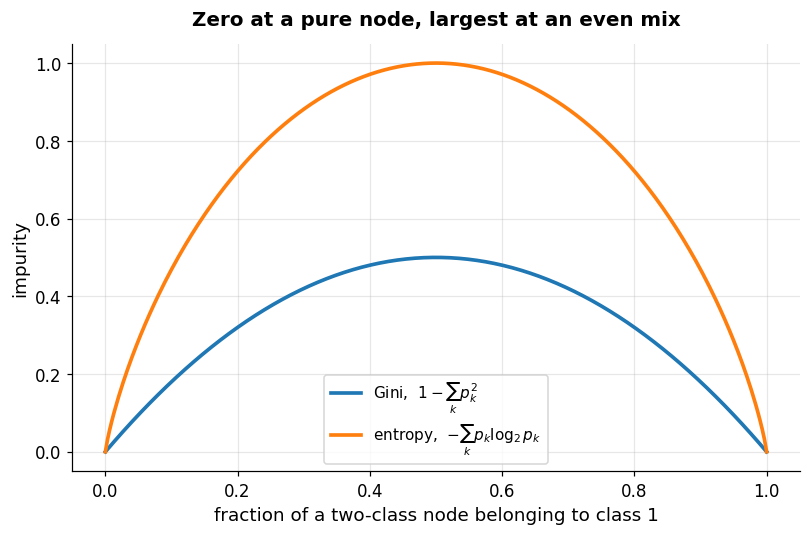

In [2]:
p = np.linspace(0, 1, 300)
gini_curve = 2 * p * (1 - p)
with np.errstate(divide="ignore", invalid="ignore"):
    entropy_curve = np.nan_to_num(-(p * np.log2(p) + (1 - p) * np.log2(1 - p)))

plt.figure(figsize=(7.5, 5))
plt.plot(p, gini_curve, linewidth=2.4, label="Gini,  $1 - \\sum_k p_k^2$")
plt.plot(p, entropy_curve, linewidth=2.4, label="entropy,  $-\\sum_k p_k \\log_2 p_k$")
plt.xlabel("fraction of a two-class node belonging to class 1")
plt.ylabel("impurity")
plt.title("Zero at a pure node, largest at an even mix")
plt.legend()
plt.show()

# 2. The split each one chooses on the iris data

Scoring every candidate threshold on both features, under both measures.

In [3]:
def impurity(mask, measure="gini"):
    """Impurity of the subset selected by a boolean mask."""
    counts = np.array([np.sum(labels[mask] == s) for s in species], dtype=float)
    proportions = counts / counts.sum()
    if measure == "gini":
        return 1 - (proportions ** 2).sum()
    nonzero = proportions[proportions > 0]
    return -(nonzero * np.log2(nonzero)).sum()

def gain_curve(feature, measure="gini"):
    """Information gain of every candidate threshold on one feature."""
    values = X_iris[feature].to_numpy()
    observed = np.unique(values)
    thresholds = (observed[:-1] + observed[1:]) / 2
    parent = impurity(np.ones(len(labels), dtype=bool), measure)

    gains = []
    for t in thresholds:
        left = values <= t
        weighted = (left.sum() * impurity(left, measure)
                    + (~left).sum() * impurity(~left, measure)) / len(labels)
        gains.append(parent - weighted)
    return thresholds, np.array(gains)

for measure in ["gini", "entropy"]:
    print(f"{measure}:   impurity of the root = "
          f"{impurity(np.ones(len(labels), dtype=bool), measure):.4f}")
    for feature in features:
        thresholds, gains = gain_curve(feature, measure)
        best = gains.argmax()
        print(f"     best split on {feature:14} :  <= {thresholds[best]:.2f}"
              f"    gain {gains[best]:.4f}")

gini:   impurity of the root = 0.6667
     best split on petal_length   :  <= 2.45    gain 0.3333
     best split on petal_width    :  <= 0.80    gain 0.3333
entropy:   impurity of the root = 1.5850
     best split on petal_length   :  <= 2.45    gain 0.9183
     best split on petal_width    :  <= 0.80    gain 0.9183


Both measures pick out the same two candidates and tie between them, so on this dataset the
choice of measure changes nothing at all. The rest of this notebook asks whether that is luck.

# 3. The two curves in the figure above look like one shape drawn at two scales, and the choice between
them looks like a matter of taste. It is very nearly a matter of taste — but only very nearly, and
the gap is the only thing that ever makes them disagree. Watch their ratio as a node gets purer.

In [4]:
def impurity_of_counts(counts, measure="gini"):
    """The same two measures, written for class counts rather than for a mask."""
    proportions = np.asarray(counts, dtype=float)
    proportions = proportions / proportions.sum()
    if measure == "gini":
        return 1 - (proportions ** 2).sum()
    nonzero = proportions[proportions > 0]
    return -(nonzero * np.log2(nonzero)).sum()

def gain_of(node, left, right, measure):
    return (impurity_of_counts(node, measure)
            - (sum(left) * impurity_of_counts(left, measure)
               + sum(right) * impurity_of_counts(right, measure)) / sum(node))

print("a two-class node, as it gets purer:")
print(f"{'p':>8}{'Gini':>9}{'entropy':>10}{'ratio':>8}")
for share in [0.5, 0.3, 0.2, 0.1, 0.05, 0.01]:
    both = [impurity_of_counts([share, 1 - share], m) for m in ["gini", "entropy"]]
    print(f"{share:>8}{both[0]:>9.3f}{both[1]:>10.3f}{both[1] / both[0]:>8.2f}")

print("\ntwo nearly worthless splits of a [40, 40] node:")
print(f"{'':>36}{'gini gain':>12}{'entropy gain':>15}")
for label, left, right in [("A: leaves one child perfectly pure", [0, 1], [40, 39]),
                           ("B: removes more mixing overall   ", [1, 3], [39, 37])]:
    print(f" {label:>35}{gain_of([40, 40], left, right, 'gini'):>12.4f}"
          f"{gain_of([40, 40], left, right, 'entropy'):>15.4f}")

a two-class node, as it gets purer:
       p     Gini   entropy   ratio
     0.5    0.500     1.000    2.00
     0.3    0.420     0.881    2.10
     0.2    0.320     0.722    2.26
     0.1    0.180     0.469    2.61
    0.05    0.095     0.286    3.01
    0.01    0.020     0.081    4.08

two nearly worthless splits of a [40, 40] node:
                                       gini gain   entropy gain
  A: leaves one child perfectly pure      0.0063         0.0126
   B: removes more mixing overall         0.0066         0.0099


In [5]:
scan = np.random.default_rng(0)
compared = disagreements = entropy_purer = entropy_smaller = 0

for _ in range(20000):
    drawn = scan.integers(5, 60, 2)
    node = [int(drawn[0]), int(drawn[1])]

    pair = []
    for _ in range(2):                                  # two candidate splits of the same node
        left = [int(scan.integers(0, node[0] + 1)), int(scan.integers(0, node[1] + 1))]
        right = [node[0] - left[0], node[1] - left[1]]
        if 0 < sum(left) < sum(node):
            pair.append((left, right))
    if len(pair) != 2:
        continue
    compared += 1

    by_gini = gain_of(node, *pair[0], "gini") - gain_of(node, *pair[1], "gini")
    by_entropy = gain_of(node, *pair[0], "entropy") - gain_of(node, *pair[1], "entropy")
    if by_gini * by_entropy >= 0:                       # they agree — nothing to learn here
        continue
    disagreements += 1

    chosen = {"entropy": pair[0] if by_entropy > 0 else pair[1],
              "gini": pair[0] if by_gini > 0 else pair[1]}
    smaller_child = {measure: min(split, key=sum) for measure, split in chosen.items()}

    entropy_purer += (impurity_of_counts(smaller_child["entropy"])
                      < impurity_of_counts(smaller_child["gini"]) - 1e-12)
    entropy_smaller += sum(smaller_child["entropy"]) < sum(smaller_child["gini"])

print(f"{compared} pairs of candidate splits compared")
print(f"   the two ranked them differently: {disagreements}"
      f"  ({100 * disagreements / compared:.1f} %)")
print(f"\nof those disagreements, entropy's choice was the one whose smaller child was")
print(f"   PURER  : {100 * entropy_purer / disagreements:5.0f} %")
print(f"   SMALLER: {100 * entropy_smaller / disagreements:5.0f} %")

19847 pairs of candidate splits compared
   the two ranked them differently: 394  (2.0 %)

of those disagreements, entropy's choice was the one whose smaller child was
   PURER  :    86 %
   SMALLER:    46 %


At an even mix entropy is exactly twice Gini, and two quantities differing by a constant factor rank
everything identically — in that region they *cannot* disagree. Towards purity the factor grows: at
$p = 0.01$ entropy charges four times what Gini does for the same sliver of contamination.

Plainly, then:

> **Entropy pays more to get rid of the last of an impurity. So when two splits score close,
> entropy leans towards the one that leaves a child perfectly clean, and Gini towards the one that
> removes more mixing in total.**

The pair of splits under the ratio table is exactly that, on one node. Both are nearly worthless.
Split A isolates a single observation in a pure child; split B removes slightly more mixing overall
but leaves both children mixed. **Gini picks B. Entropy picks A.**

The scan above turns that one example into a rate. It takes twenty thousand random nodes, offers
each a pair of candidate splits, and asks how often the two measures rank them differently. The
answer is **2.0%** — the two agree about which of two splits is better forty-nine times in fifty.
That number is not particular to this scan; it is the standard result for these two measures.

But the 2% is not random noise, and that is the point. In **86%** of the disagreements, entropy's
choice is the one whose smaller child is purer. The preference is rare *and* systematic.

Note what the same scan does *not* say. Entropy's choice has the *smaller* small child only 46% of
the time — slightly less often than Gini's, so if anything its splits are marginally more balanced.
The preference is about **purity, not about size**.

### Is that a reason to prefer Gini?

It is the natural worry, and a good one. A split that isolates a handful of observations in a pure
node is exactly the kind of rule that describes the sample rather than the population — section 4's
last panel will show one doing precisely that. If entropy leans that way at every split, entropy
trees ought to come out more fragmented.

They do not, and that is worth seeing rather than assuming. Below, both measures grow unpruned trees
on sixty resamples of two datasets: the iris flowers, and a deliberately nasty synthetic problem
with six features of which only two carry signal and a quarter of the labels flipped.

In [6]:
noise_rng = np.random.default_rng(1)
noisy = pd.DataFrame(noise_rng.normal(0, 1, (400, 6)), columns=[f"x{i}" for i in range(6)])
honest_label = (noisy["x0"] + noisy["x1"] > 0).astype(int)
noisy_label = (honest_label ^ (noise_rng.random(400) < 0.25)).astype(int)   # a quarter mislabelled

print(f"{'':>18}{'leaves grown':>20}{'leaves holding <= 2':>24}")
print(f"{'dataset':>18}{'gini / entropy':>20}{'gini / entropy':>24}")
for name, frame, target in [("iris", X_iris, y_iris),
                            ("noisy synthetic", noisy, noisy_label)]:
    summary = {}
    for measure in ["gini", "entropy"]:
        boot = np.random.default_rng(4)              # the same 60 resamples for both measures
        leaves, tiny = [], []
        for _ in range(60):
            rows = boot.integers(0, len(target), len(target))
            grown_tree = DecisionTreeClassifier(criterion=measure, random_state=0).fit(
                frame.iloc[rows], np.asarray(target)[rows])
            sizes = np.bincount(grown_tree.apply(frame.iloc[rows]))
            leaves.append(grown_tree.get_n_leaves())
            tiny.append(int(((sizes > 0) & (sizes <= 2)).sum()))
        summary[measure] = (np.mean(leaves), np.mean(tiny))
    print(f"{name:>18}{summary['gini'][0]:>11.1f} /{summary['entropy'][0]:>8.1f}"
          f"{summary['gini'][1]:>15.1f} /{summary['entropy'][1]:>8.1f}")

                          leaves grown     leaves holding <= 2
           dataset      gini / entropy          gini / entropy


              iris        6.8 /     6.9            2.2 /     2.1


   noisy synthetic       64.0 /    59.7           30.4 /    22.4


On iris the two are indistinguishable. On the nasty problem entropy grows **fewer** leaves,
and noticeably fewer leaves holding only one or two observations — the opposite of what the
split-by-split preference would suggest.

There is no contradiction with the 2% above, and the reconciliation is worth having. **Rare is not
the same as negligible when it is also systematic.** The tree on the nasty problem makes about sixty
splits; a preference acted on in a small fraction of them, but always leaning the same way, is
visible in a leaf count. What it is *not* visible in is the direction the worry predicted.

So a rule applied at every split does not accumulate in the obvious way, and it is not worth
guessing why. The useful conclusion is the one the numbers support: **the impurity measure is not
the instrument for controlling fragmentation.** Section 6 is. Pruning removes undeserving leaves
whichever measure proposed them, and it decides by asking whether they earn their keep on held-out
data — a question neither Gini nor entropy is trying to answer.

That leaves the thing you would actually notice: whether the choice moves a prediction.

In [7]:
def questions_asked(model):
    """The sequence of questions a fitted tree asks, as something comparable."""
    return (tuple(model.tree_.feature), tuple(np.round(model.tree_.threshold, 6)))

shuffle = np.random.default_rng(0)
differ_by_criterion = differ_by_data = 0
previous = None

for _ in range(200):
    rows = shuffle.integers(0, len(y_iris), len(y_iris))
    grown = [DecisionTreeClassifier(max_depth=3, random_state=0, criterion=measure)
             .fit(X_iris.iloc[rows], y_iris.iloc[rows]) for measure in ["gini", "entropy"]]
    differ_by_criterion += questions_asked(grown[0]) != questions_asked(grown[1])
    if previous is not None:
        differ_by_data += questions_asked(grown[0]) != previous
    previous = questions_asked(grown[0])

print("over 200 resamples of the same 150 flowers, how often does the tree change?")
print(f"   change the criterion, keep the data:  {differ_by_criterion:>4} / 200")
print(f"   change the data, keep the criterion:  {differ_by_data:>4} / 199")

print(f"\n{'max_depth':>10}{'gini':>9}{'entropy':>10}      cross-validated accuracy")
for depth in [2, 3, 4, None]:
    scored = [cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=0,
                                                     criterion=measure),
                              X_iris, y_iris, cv=5).mean()
              for measure in ["gini", "entropy"]]
    print(f"{str(depth):>10}{scored[0]:>9.3f}{scored[1]:>10.3f}")

over 200 resamples of the same 150 flowers, how often does the tree change?
   change the criterion, keep the data:    69 / 200
   change the data, keep the criterion:   199 / 199

 max_depth     gini   entropy      cross-validated accuracy
         2    0.933     0.933
         3    0.960     0.960
         4    0.953     0.960
      None    0.947     0.953


It does not — and now the whole answer can be assembled, because "are the two measures different?"
turns out to have three different answers depending on what you measure.

**Per decision, they almost always agree.** Two per cent of the time they rank a pair of splits
differently.

**Per tree, they often differ.** A tree makes many splits, each another opportunity, and a single
disagreement rewrites everything beneath it — so 69 of 200 resamples give a different tree. Read
that against the line below it, though: resampling the same 150 flowers changes the tree in 199
cases out of 199. The criterion is a small perturbation sitting on top of a very large one, and
section 8.3 is about the large one.

**Per prediction, nothing moves.** Cross-validated accuracy is identical at the depths worth using
and differs by a single flower elsewhere, in whichever direction the resampling happens to push it.

The honest summary is therefore neither "they are the same" nor "they are different". It is that
**they encode a real and systematic preference, they act on it rarely, and when they do act on it,
nothing you were trying to measure moves.**

So use Gini, which is the default. Two things might make you change your mind, and neither is
accuracy.

> **Reference.** That the two criteria select different splits in only a small percentage of cases,
> and the conditions under which they part company, are the subject of L. E. Raileanu and K. Stoffel,
> "Theoretical comparison between the Gini index and information gain criteria", *Annals of
> Mathematics and Artificial Intelligence* **41** (2004) 77–93.
>
> **Cost.** Gini needs multiplications; entropy needs a logarithm for every class at every candidate
> threshold. It is a small constant factor, and it is why CART chose Gini while ID3 and C4.5 chose
> entropy. It is rarely the deciding consideration now.
>
> **Meaning.** Entropy's information gain is a genuine information-theoretic quantity: the reduction
> in uncertainty about the class, measured in **bits**, bought by learning the answer to the
> question. If you want to write "that question was worth 0.92 bits", entropy is the measure that
> makes the sentence true. Gini's gain supports no such reading. The two are also not comparable
> numbers — on $K$ classes Gini tops out at $1 - 1/K$ and entropy at $\log_2 K$ — so a gain of
> 0.3333 and a gain of 0.9183 can describe the very same split, as they did at the root above.

# 4. Why this was cut

The conclusion above is that the two measures encode a real and systematic preference, act on it in
about 2% of decisions, and produce no difference in anything a user of the model would measure.

That is a defensible thing to know and a poor thing to teach in an hour that has to cover
partitioning, impurity, information gain, depth, pruning, regression trees and instability. It is
also an implementation detail rather than a modelling assumption: it says nothing about the data,
only about how one library breaks near-ties. `04A` therefore uses Gini throughout, silently, as
`scikit-learn` does.